In [74]:
import kagglehub
path = kagglehub.dataset_download("olgagmiufana1/fragrantica-com-fragrance-dataset")
print("Path to dataset files:", path)

Path to dataset files: /home/abraao/.cache/kagglehub/datasets/olgagmiufana1/fragrantica-com-fragrance-dataset/versions/3


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv("/home/abraao/.cache/kagglehub/datasets/olgagmiufana1/fragrantica-com-fragrance-dataset/versions/3/fra_cleaned.csv", encoding="latin-1", sep=";")

dataset = dataset.drop(columns=["url"])
dataset["Brand"] = dataset["Brand"].astype("category")
dataset["Gender"] = dataset["Gender"].astype("category")

def clean_dataset(df):
    df = df.copy()

    # Corrigir rating
    df["Rating Value"] = (
        df["Rating Value"]
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

    return df

dataset = clean_dataset(dataset)

In [76]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 24063 entries, 0 to 24062
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Perfume       24063 non-null  str     
 1   Brand         24063 non-null  category
 2   Country       24063 non-null  str     
 3   Gender        24063 non-null  category
 4   Rating Value  24063 non-null  float64 
 5   Rating Count  24063 non-null  int64   
 6   Year          22026 non-null  float64 
 7   Top           24063 non-null  str     
 8   Middle        24063 non-null  str     
 9   Base          24063 non-null  str     
 10  Perfumer1     24063 non-null  str     
 11  Perfumer2     1336 non-null   str     
 12  mainaccord1   24063 non-null  str     
 13  mainaccord2   24050 non-null  str     
 14  mainaccord3   23949 non-null  str     
 15  mainaccord4   23675 non-null  str     
 16  mainaccord5   23082 non-null  str     
dtypes: category(2), float64(2), int64(1), str(12)
memory usage: 2

In [77]:
dataset.head()

,Perfume,Brand,Country,Gender,Rating Value,Rating Count,Year,Top,Middle,Base,Perfumer1,Perfumer2,mainaccord1,mainaccord2,mainaccord3,mainaccord4,mainaccord5
0,accento-overdose-pride-edition,xerjoff,Italy,unisex,1.42,201,2022.0,"fruity notes, aldehydes, green notes","bulgarian rose, egyptian jasmine, lily-of-the-...","eucalyptus, pine",unknown,NaN,rose,woody,fruity,aromatic,floral
1,classique-pride-2024,jean-paul-gaultier,France,women,1.86,70,2024.0,"yuzu, citruses","orange blossom, neroli","musk, blonde woods",unknown,NaN,citrus,white floral,sweet,fresh,musky
2,classique-pride-2023,jean-paul-gaultier,France,unisex,1.91,285,2023.0,"blood orange, yuzu","neroli, orange blossom","musk, white woods",natalie gracia-cetto,quentin bisch,citrus,white floral,sweet,fresh spicy,musky
3,pride-edition-man,bruno-banani,Germany,men,1.92,59,2019.0,"guarana, grapefruit, red apple","walnut, lavender, guava","vetiver, benzoin, amber",unknown,NaN,fruity,nutty,woody,tropical,NaN
4,le-male-pride-collector,jean-paul-gaultier,France,men,1.93,632,2020.0,"mint, lavender, cardamom, artemisia, bergamot","caraway, cinnamon, orange blossom","vanilla, sandalwood, amber, cedar, tonka bean",francis kurkdjian,NaN,aromatic,warm spicy,fresh spicy,cinnamon,vanilla


In [78]:
def filter_by_brand(df, brand):
    return df[df["Brand"] == brand]

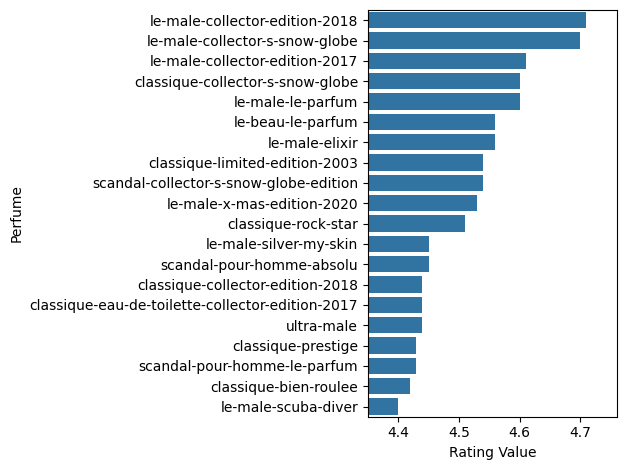

In [83]:
jpg_dataset = filter_by_brand(dataset, "jean-paul-gaultier")
top_rated_jpg_perfumes = jpg_dataset.nlargest(20, 'Rating Value')

sns.barplot(data=top_rated_jpg_perfumes, x="Rating Value", y="Perfume", orient='h')
plt.xlim(top_rated_jpg_perfumes['Rating Value'].min() - 0.05,
         top_rated_jpg_perfumes['Rating Value'].max() + 0.05)
plt.tight_layout()
plt.show()